In [39]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [40]:
all_data = pd.concat([df_train, df_test], sort=True).reset_index(drop=True)

In [41]:
all_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1046.0,29.881138,14.413493,0.17,21.0000,28.0000,39.000,80.0000
Fare,1308.0,33.295479,51.758668,0.00,7.8958,14.4542,31.275,512.3292
Parch,1309.0,0.385027,0.865560,0.00,0.0000,0.0000,0.000,9.0000
PassengerId,1309.0,655.000000,378.020061,1.00,328.0000,655.0000,982.000,1309.0000
Pclass,1309.0,2.294882,0.837836,1.00,2.0000,3.0000,3.000,3.0000
SibSp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.000,1.0000


In [42]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1046 non-null   float64
 1   Cabin        295 non-null    object 
 2   Embarked     1307 non-null   object 
 3   Fare         1308 non-null   float64
 4   Name         1309 non-null   object 
 5   Parch        1309 non-null   int64  
 6   PassengerId  1309 non-null   int64  
 7   Pclass       1309 non-null   int64  
 8   Sex          1309 non-null   object 
 9   SibSp        1309 non-null   int64  
 10  Survived     891 non-null    float64
 11  Ticket       1309 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [43]:
all_data.corr()

,Age,Fare,Parch,PassengerId,Pclass,SibSp,Survived
Age,1.000000,0.178740,-0.150917,0.028814,-0.408106,-0.243699,-0.077221
Fare,0.178740,1.000000,0.221539,0.031428,-0.558629,0.160238,0.257307
Parch,-0.150917,0.221539,1.000000,0.008942,0.018322,0.373587,0.081629
PassengerId,0.028814,0.031428,0.008942,1.000000,-0.038354,-0.055224,-0.005007
Pclass,-0.408106,-0.558629,0.018322,-0.038354,1.000000,0.060832,-0.338481
SibSp,-0.243699,0.160238,0.373587,-0.055224,0.060832,1.000000,-0.035322
Survived,-0.077221,0.257307,0.081629,-0.005007,-0.338481,-0.035322,1.000000


In [44]:
all_data.corr().abs()['Age'].sort_values(ascending=False)

Age            1.000000
Pclass         0.408106
SibSp          0.243699
Fare           0.178740
Parch          0.150917
Survived       0.077221
PassengerId    0.028814
Name: Age, dtype: float64

Age is correlated to passenger class. We will also use sex to determine median age for filling null values.

In [45]:
all_data.groupby(['Sex', 'Pclass']).median()['Age']

Sex     Pclass
female  1         36.0
        2         28.0
        3         22.0
male    1         42.0
        2         29.5
        3         25.0
Name: Age, dtype: float64

In [46]:
all_data['Age'] = all_data.groupby(['Sex', 'Pclass'])['Age'].apply(lambda x: x.fillna(x.median()))

In [47]:
all_data[all_data['Embarked'].isnull()]

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
61,38.0,B28,NaN,80.0,"Icard, Miss. Amelie",0,62,1,female,0,1.0,113572
829,62.0,B28,NaN,80.0,"Stone, Mrs. George Nelson (Martha Evelyn)",0,830,1,female,0,1.0,113572


In [48]:
# find this data through Google
all_data['Embarked'] = all_data['Embarked'].fillna('S')

In [49]:
all_data[all_data['Fare'].isnull()]

,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
1043,60.5,NaN,S,NaN,"Storey, Mr. Thomas",0,1044,3,male,0,NaN,3701


This passenger has no family and is in 3rd class. Find median for a male with these characteristics.

In [50]:
med_fare = all_data.groupby(['Pclass', 'Parch', 'SibSp'])['Fare'].median()[3][0][0]
all_data['Fare'] = all_data['Fare'].fillna(med_fare)

In [51]:
all_data['Deck'] = all_data['Cabin'].apply(lambda s: s[0] if pd.notnull(s) else 'M')
idx = all_data[all_data['Deck'] == 'T'].index
all_data.loc[idx, 'Deck'] = 'A'

In [52]:
all_data['Deck'] = all_data['Deck'].replace(['A', 'B', 'C'], 'ABC')
all_data['Deck'] = all_data['Deck'].replace(['D', 'E'], 'DE')
all_data['Deck'] = all_data['Deck'].replace(['F', 'G'], 'FG')

all_data['Deck'].value_counts()

M      1014
ABC     182
DE       87
FG       26
Name: Deck, dtype: int64

In [53]:
all_data.drop(['Cabin'], inplace=True, axis=1)

In [54]:
df_train = all_data[~all_data['Survived'].isna()]
df_test = all_data[all_data['Survived'].isna()]

In [55]:
df_train['Survived'].value_counts() / len(df_train) * 100

0.0    61.616162
1.0    38.383838
Name: Survived, dtype: float64

In [56]:
df_train_corr = df_train.drop(['PassengerId'], axis=1).corr().abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
df_train_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: 'Correlation Coefficient'}, inplace=True)
df_train_corr.drop(df_train_corr.iloc[1::2].index, inplace=True)
df_train_corr_nd = df_train_corr.drop(df_train_corr[df_train_corr['Correlation Coefficient'] == 1.0].index)

corr = df_train_corr_nd['Correlation Coefficient'] > 0.1
df_train_corr_nd[corr]

,Feature 1,Feature 2,Correlation Coefficient
6,Pclass,Fare,0.549500
8,Pclass,Age,0.417667
10,SibSp,Parch,0.414838
12,Survived,Pclass,0.338481
14,Survived,Fare,0.257307
16,SibSp,Age,0.249747
18,Parch,Fare,0.216225
20,Age,Parch,0.176733
22,SibSp,Fare,0.159651
24,Age,Fare,0.124061


Continuous: Age, Fare
Categorical: Everything else

In [57]:
all_data['Fare'] = pd.qcut(all_data['Fare'], 13)

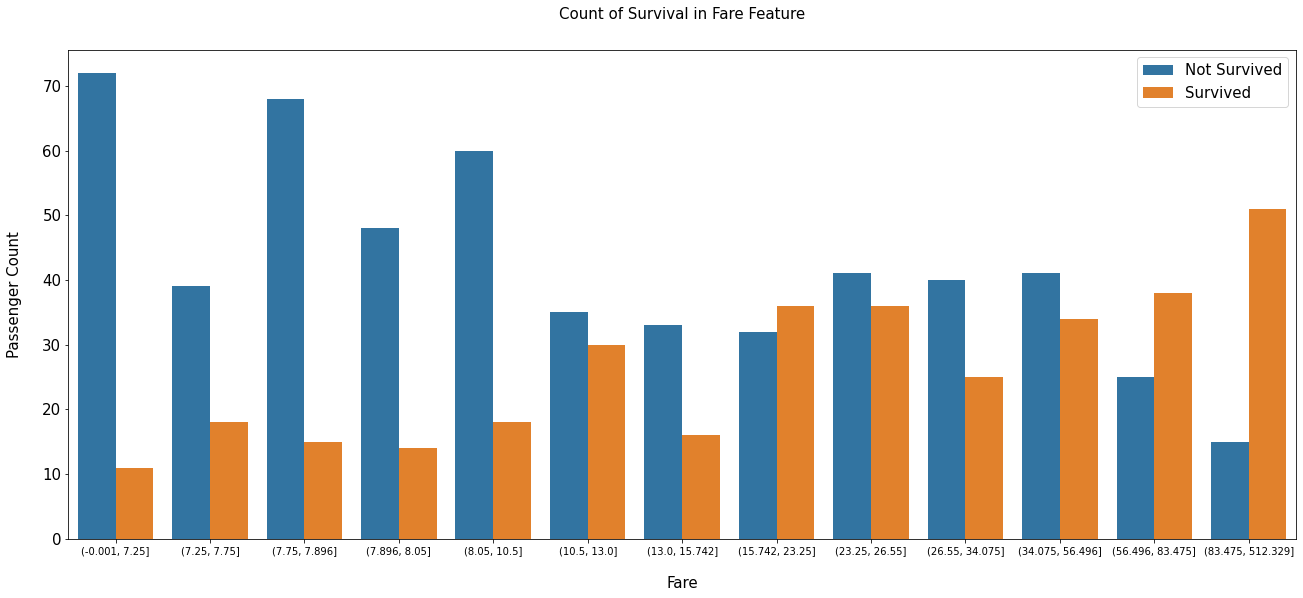

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='Fare', hue='Survived', data=all_data)

plt.xlabel('Fare', size=15, labelpad=20)
plt.ylabel('Passenger Count', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 15})
plt.title('Count of Survival in {} Feature'.format('Fare'), size=15, y=1.05)

plt.show()

In [59]:
all_data['Age'] = pd.qcut(all_data['Age'], 10)

In [60]:
all_data['Family Size'] = all_data['SibSp'] + all_data['Parch'] + 1
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4: 'Small', 5: 'Medium', 6: 'Medium', 7: 'Large', 8: 'Large', 11: 'Large'}
all_data['Family Size Grouped'] = all_data['Family Size'].map(family_map)

In [61]:
all_data['Ticket Frequency'] = all_data.groupby('Ticket')['Ticket'].transform('count')

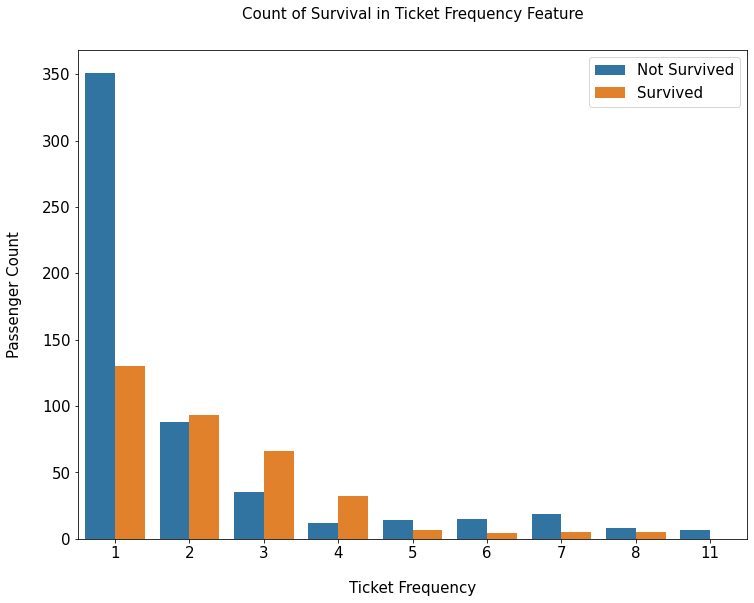

In [62]:
fig, axs = plt.subplots(figsize=(12, 9))
sns.countplot(x='Ticket Frequency', hue='Survived', data=all_data)

plt.xlabel('Ticket Frequency', size=15, labelpad=20)
plt.ylabel('Passenger Count', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 15})
plt.title('Count of Survival in {} Feature'.format('Ticket Frequency'), size=15, y=1.05)

plt.show()

In [63]:
all_data['Title'] = all_data['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
all_data['Is Married'] = 0
all_data['Is Married'].loc[all_data['Title'] == 'Mrs'] = 1

/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/pandas/core/indexing.py:671: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_with_indexer(indexer, value)


In [64]:
import string

def extract_surname(data):    
    
    families = []
    
    for i in range(len(data)):        
        name = data.iloc[i]

        if '(' in name:
            name_no_bracket = name.split('(')[0] 
        else:
            name_no_bracket = name
            
        family = name_no_bracket.split(',')[0]
        title = name_no_bracket.split(',')[1].strip().split(' ')[0]
        
        for c in string.punctuation:
            family = family.replace(c, '').strip()
            
        families.append(family)
            
    return families

all_data['Family'] = extract_surname(all_data['Name'])

In [65]:
df_train = all_data[~all_data['Survived'].isna()]
df_test = all_data[all_data['Survived'].isna()]

In [66]:
non_unique_families = [x for x in df_train['Family'].unique() if x in df_test['Family'].unique()]
non_unique_tickets = [x for x in df_train['Ticket'].unique() if x in df_test['Ticket'].unique()]

df_family_survival_rate = df_train.groupby('Family')['Survived', 'Family','Family Size'].median()
df_ticket_survival_rate = df_train.groupby('Ticket')['Survived', 'Ticket','Ticket Frequency'].median()

family_rates = {}
ticket_rates = {}

for i in range(len(df_family_survival_rate)):
    # Checking a family exists in both training and test set, and has members more than 1
    if df_family_survival_rate.index[i] in non_unique_families and df_family_survival_rate.iloc[i, 1] > 1:
        family_rates[df_family_survival_rate.index[i]] = df_family_survival_rate.iloc[i, 0]

for i in range(len(df_ticket_survival_rate)):
    # Checking a ticket exists in both training and test set, and has members more than 1
    if df_ticket_survival_rate.index[i] in non_unique_tickets and df_ticket_survival_rate.iloc[i, 1] > 1:
        ticket_rates[df_ticket_survival_rate.index[i]] = df_ticket_survival_rate.iloc[i, 0]

<ipython-input-66-7bd63c36834a>:4: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_family_survival_rate = df_train.groupby('Family')['Survived', 'Family','Family Size'].median()
<ipython-input-66-7bd63c36834a>:5: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_ticket_survival_rate = df_train.groupby('Ticket')['Survived', 'Ticket','Ticket Frequency'].median()


In [67]:
import numpy as np

mean_survival_rate = np.mean(df_train['Survived'])

train_family_survival_rate = []
train_family_survival_rate_NA = []
test_family_survival_rate = []
test_family_survival_rate_NA = []

for i in range(len(df_train)):
    if df_train['Family'][i] in family_rates:
        train_family_survival_rate.append(family_rates[df_train['Family'][i]])
        train_family_survival_rate_NA.append(1)
    else:
        train_family_survival_rate.append(mean_survival_rate)
        train_family_survival_rate_NA.append(0)
        
for i in range(len(df_test)):
    if df_test['Family'].iloc[i] in family_rates:
        test_family_survival_rate.append(family_rates[df_test['Family'].iloc[i]])
        test_family_survival_rate_NA.append(1)
    else:
        test_family_survival_rate.append(mean_survival_rate)
        test_family_survival_rate_NA.append(0)
        
df_train['Family_Survival_Rate'] = train_family_survival_rate
df_train['Family_Survival_Rate_NA'] = train_family_survival_rate_NA
df_test['Family_Survival_Rate'] = test_family_survival_rate
df_test['Family_Survival_Rate_NA'] = test_family_survival_rate_NA

train_ticket_survival_rate = []
train_ticket_survival_rate_NA = []
test_ticket_survival_rate = []
test_ticket_survival_rate_NA = []

for i in range(len(df_train)):
    if df_train['Ticket'][i] in ticket_rates:
        train_ticket_survival_rate.append(ticket_rates[df_train['Ticket'][i]])
        train_ticket_survival_rate_NA.append(1)
    else:
        train_ticket_survival_rate.append(mean_survival_rate)
        train_ticket_survival_rate_NA.append(0)
        
for i in range(len(df_test)):
    if df_test['Ticket'].iloc[i] in ticket_rates:
        test_ticket_survival_rate.append(ticket_rates[df_test['Ticket'].iloc[i]])
        test_ticket_survival_rate_NA.append(1)
    else:
        test_ticket_survival_rate.append(mean_survival_rate)
        test_ticket_survival_rate_NA.append(0)
        
df_train['Ticket_Survival_Rate'] = train_ticket_survival_rate
df_train['Ticket_Survival_Rate_NA'] = train_ticket_survival_rate_NA
df_test['Ticket_Survival_Rate'] = test_ticket_survival_rate
df_test['Ticket_Survival_Rate_NA'] = test_ticket_survival_rate_NA

<ipython-input-67-551b915de301>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Family_Survival_Rate'] = train_family_survival_rate
<ipython-input-67-551b915de301>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Family_Survival_Rate_NA'] = train_family_survival_rate_NA
<ipython-input-67-551b915de301>:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [68]:
for df in [df_train, df_test]:
    df['Survival_Rate'] = (df['Ticket_Survival_Rate'] + df['Family_Survival_Rate']) / 2
    df['Survival_Rate_NA'] = (df['Ticket_Survival_Rate_NA'] + df['Family_Survival_Rate_NA']) / 2  

<ipython-input-68-7b2ea0b163c5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Survival_Rate'] = (df['Ticket_Survival_Rate'] + df['Family_Survival_Rate']) / 2
<ipython-input-68-7b2ea0b163c5>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Survival_Rate_NA'] = (df['Ticket_Survival_Rate_NA'] + df['Family_Survival_Rate_NA']) / 2


Embarked, Sex, Deck , Title and Family_Size_Grouped are object type, and Age and Fare features are category type. They are converted to numerical type with LabelEncoder.

In [69]:
from sklearn.preprocessing import LabelEncoder

non_numeric_features = ['Embarked', 'Sex', 'Deck', 'Title', 'Family Size Grouped', 'Age', 'Fare']

for df in [df_train, df_test]:
    for feature in non_numeric_features:        
        df[feature] = LabelEncoder().fit_transform(df[feature])

<ipython-input-69-eab012f37f74>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature] = LabelEncoder().fit_transform(df[feature])


In [70]:
from sklearn.preprocessing import OneHotEncoder

cat_features = ['Pclass', 'Sex', 'Deck', 'Embarked', 'Title', 'Family Size Grouped']
encoded_features = []

for df in [df_train, df_test]:
    for feature in cat_features:
        encoded_feat = OneHotEncoder().fit_transform(df[feature].values.reshape(-1, 1)).toarray()
        n = df[feature].nunique()
        cols = ['{}_{}'.format(feature, n) for n in range(1, n + 1)]
        encoded_df = pd.DataFrame(encoded_feat, columns=cols)
        encoded_df.index = df.index
        encoded_features.append(encoded_df)

df_train = pd.concat([df_train, *encoded_features[:6]], axis=1)
df_test = pd.concat([df_test, *encoded_features[6:]], axis=1)

In [84]:
df_all = pd.concat([df_train, df_test], sort=True).reset_index(drop=True)
drop_cols = ['Deck', 'Embarked', 'Family', 'Family Size', 'Family Size Grouped', 'Survived',
             'Name', 'Parch', 'PassengerId', 'Pclass', 'Sex', 'SibSp', 'Ticket', 'Title',
            'Ticket_Survival_Rate', 'Family_Survival_Rate', 'Ticket_Survival_Rate_NA', 'Family_Survival_Rate_NA']

df_all.drop(columns=drop_cols, inplace=True)

df_all.head()

,Age,Deck_1,Deck_2,Deck_3,Deck_4,Embarked_1,Embarked_2,Embarked_3,Family Size Grouped_1,Family Size Grouped_2,...,Title_16,Title_17,Title_2,Title_3,Title_4,Title_5,Title_6,Title_7,Title_8,Title_9
0,2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,7,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
from sklearn.preprocessing import StandardScaler

X_train = StandardScaler().fit_transform(df_train.drop(columns=drop_cols + ['Title_10',
 'Title_11',
 'Title_12',
 'Title_13',
 'Title_14',
 'Title_15',
 'Title_16',
 'Title_17']))
y_train = df_train['Survived'].values
X_test = StandardScaler().fit_transform(df_test.drop(columns=drop_cols))

In [88]:
print(X_train.shape)
print(X_test.shape)

(891, 31)
(418, 31)


In [89]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

def evaluate_model(name, model, x, y):
    print(f'Evaluating {name}...')
    scores = cross_val_score(model, x, y)
    mean_score = scores.mean()
    print(f'Average accuracy during cross validation: {mean_score}\n')
    return mean_score
#     model.fit(x, y)
#     predictions = model.predict(x)
#     print(classification_report(y, predictions))

In [90]:
best_model = ''
best_score = float('-inf')
for name, model in [
    ('log_reg', LogisticRegression()),
    ('svc', SVC(C=1)),
    ('decision_tree', DecisionTreeClassifier()),
    ('extra_trees', ExtraTreeClassifier()),
    ('k_neighbors', KNeighborsClassifier(n_neighbors=1)),
    ('grad_boost', GradientBoostingClassifier()),
    ('rand_forest', RandomForestClassifier()),
    ('mlp', MLPClassifier())
]:
    score = evaluate_model(name, model, X_train, y_train)
    if score > best_score:
        best_score = score
        best_model = name
print("Best model: ", best_model)

Evaluating log_reg...
Average accuracy during cross validation: 0.8506998932898122

Evaluating svc...
Average accuracy during cross validation: 0.8394827694432239

Evaluating decision_tree...
Average accuracy during cross validation: 0.8159374803841567

Evaluating extra_trees...
Average accuracy during cross validation: 0.8024543343167411

Evaluating k_neighbors...
Average accuracy during cross validation: 0.7800263636934279

Evaluating grad_boost...
Average accuracy during cross validation: 0.8529784696503672

Evaluating rand_forest...
Average accuracy during cross validation: 0.8293955181721173

Evaluating mlp...


/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.wa

Average accuracy during cross validation: 0.840631473228297

Best model:  grad_boost


/home/admin/.pyenv/versions/3.8.2/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:582: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [107]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = [
    {
        'n_estimators': [10, 100, 1000], 
        'max_depth': [None, 3, 4, 16],
        'max_features': [None, 2, 4, 8],
        'max_leaf_nodes': [None, 2, 4, 16],
    },
]

rfc = RandomForestClassifier()
grid_search = RandomizedSearchCV(rfc, param_grid, cv=5, 
                           scoring='accuracy', 
                           return_train_score=True, refit=True)
grid_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions=[{'max_depth': [None, 3, 4, 16],
                                         'max_features': [None, 2, 4, 8],
                                         'max_leaf_nodes': [None, 2, 4, 16],
                                         'n_estimators': [10, 100, 1000]}],
                   return_train_score=True, scoring='accuracy')

In [108]:
final_model = grid_search.best_estimator_

final_predictions = final_model.predict(X_train)
print(classification_report(y_train, final_predictions))

              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91       549
         1.0       0.89      0.81      0.85       342

    accuracy                           0.89       891
   macro avg       0.89      0.87      0.88       891
weighted avg       0.89      0.89      0.89       891



In [109]:
test_predictions = final_model.predict(X_test).astype(int)

In [113]:
single_best_model = RandomForestClassifier(criterion='gini', 
                                           n_estimators=1100,
                                           max_depth=5,
                                           min_samples_split=4,
                                           min_samples_leaf=5,
                                           max_features='auto',
                                           oob_score=True,
                                           random_state=42,
                                           n_jobs=-1,
                                           verbose=1)

In [114]:
single_best_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 442 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 792 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 1100 out of 1100 | elapsed:    2.0s finished


RandomForestClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=4,
                       n_estimators=1100, n_jobs=-1, oob_score=True,
                       random_state=42, verbose=1)

In [115]:
final_predictions = single_best_model.predict(X_train)
print(classification_report(y_train, final_predictions))

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.2s


              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88       549
         1.0       0.84      0.75      0.79       342

    accuracy                           0.85       891
   macro avg       0.85      0.83      0.84       891
weighted avg       0.85      0.85      0.85       891



[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 1100 out of 1100 | elapsed:    0.3s finished


In [116]:
test_predictions = single_best_model.predict(X_test).astype(int)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 1100 out of 1100 | elapsed:    0.3s finished


In [117]:
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': test_predictions
})

submission.to_csv('submission.csv', index=False)

In [111]:
from tensorflow import keras

# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train_prepared)
# x_test_scaled = scaler.transform(x_test_prepared)

model = keras.models.Sequential([
    keras.layers.Dense(32, input_shape=(X_train.shape[1],), activation='elu', kernel_initializer="he_normal"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(20, activation='elu', kernel_initializer="he_normal"),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=50)

Epoch 1/50
28/28 [==============================] - 0s 1ms/step - loss: 0.7365 - accuracy: 0.6139
Epoch 2/50
28/28 [==============================] - 0s 2ms/step - loss: 0.5184 - accuracy: 0.7598
Epoch 3/50
28/28 [==============================] - 0s 2ms/step - loss: 0.4515 - accuracy: 0.7957
Epoch 4/50
28/28 [==============================] - 0s 3ms/step - loss: 0.4393 - accuracy: 0.8126
Epoch 5/50
28/28 [==============================] - 0s 3ms/step - loss: 0.4000 - accuracy: 0.8260
Epoch 6/50
28/28 [==============================] - 0s 2ms/step - loss: 0.4127 - accuracy: 0.8171
Epoch 7/50
28/28 [==============================] - 0s 3ms/step - loss: 0.4012 - accuracy: 0.8350
Epoch 8/50
28/28 [==============================] - 0s 2ms/step - loss: 0.3703 - accuracy: 0.8474
Epoch 9/50
28/28 [==============================] - 0s 3ms/step - loss: 0.3736 - accuracy: 0.8418
Epoch 10/50
28/28 [==============================] - 0s 3ms/step - loss: 0.3819 - accuracy: 0.8373
Epoch 11/50
28/28 [

In [103]:
predictions = np.squeeze((model.predict(X_test) > 0.5).astype("int32"))

In [105]:
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': predictions
})

submission.to_csv('submission_keras.csv', index=False)